<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
label
ham     4516
spam     653
Name: count, dtype: int64


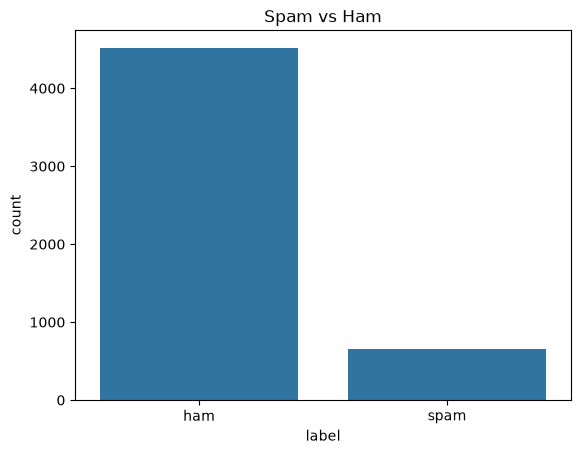

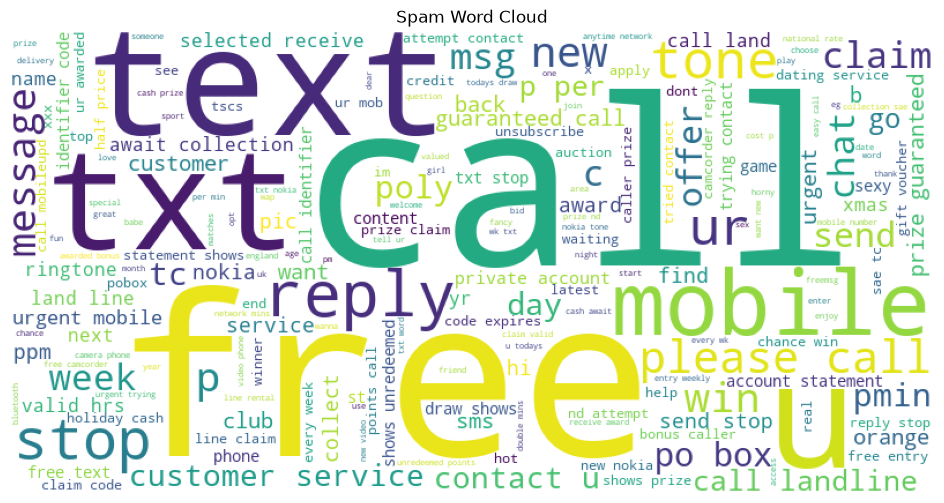

Naive Bayes Results
Accuracy : 0.9671179883945842
Precision: 1.0
Recall : 0.7571428571428571
F1 Score : 0.8617886178861789
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       894
           1       1.00      0.76      0.86       140

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

Logistic Regression Results
Accuracy : 0.9497098646034816
Precision: 0.9680851063829787
Recall : 0.65
F1 Score : 0.7777777777777778
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       894
           1       0.97      0.65      0.78       140

    accuracy                           0.95      1034
   macro avg       0.96      0.82      0.87      1034
weighted avg       0.95      0.95      0.95      1034



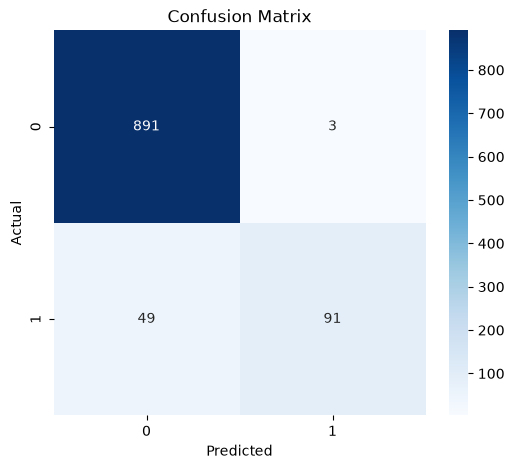

Not Spam


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from wordcloud import WordCloud
data = pd.read_csv("SMSSpamCollection",sep="\t",names=["label","message"])
data.head()
data.info()
data.isnull().sum()
data=data.drop_duplicates()
print(data['label'].value_counts())
sns.countplot(x=data['label'])
plt.title("Spam vs Ham")
plt.show()
data['label']=data['label'].map({'ham':0,'spam':1})
data.head()
stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+','',text)
    text=text.translate(str.maketrans('','',string.punctuation))
    words=text.split()
    words=[word for word in words if word not in stop_words]
    return " ".join(words)
data['message']=data['message'].apply(clean_text)
data.head()
spam_words=" ".join(data[data.label==1]['message'])
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(spam_words)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Spam Word Cloud")
plt.show()
tfidf=TfidfVectorizer()
X=tfidf.fit_transform(data['message'])
y=data['label']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)
nb=MultinomialNB()
nb.fit(X_train,y_train)
nb_pred=nb.predict(X_test)
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print("Naive Bayes Results")
print("Accuracy :",accuracy_score(y_test,nb_pred))
print("Precision:",precision_score(y_test,nb_pred))
print("Recall :",recall_score(y_test,nb_pred))
print("F1 Score :",f1_score(y_test,nb_pred))
print(classification_report(y_test,nb_pred))
print("Logistic Regression Results")
print("Accuracy :",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred))
print("Recall :",recall_score(y_test,lr_pred))
print("F1 Score :",f1_score(y_test,lr_pred))
print(classification_report(y_test,lr_pred))
cm=confusion_matrix(y_test,lr_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
message=["Congratulations! You have won a free iPhone. Click now."]
message=tfidf.transform(message)
prediction=lr.predict(message)
if prediction[0]==1:
    print("Spam Message")
else:
    print("Not Spam")